# ***Amazon Product Performance Analysis using Python & Power BI***

**Business Problem**

Amazon sells thousands of products across multiple categories. Understanding which products perform well, how discounts relate to customer ratings, and which categories contribute the most to overall product performance can help support better pricing, marketing, and inventory decisions.

In this project, I analyzed Amazon product data using Python and Power BI to explore product performance, pricing, discounts, customer ratings, and review engagement. The goal was to identify meaningful patterns and insights that could support data-driven business decisions.


  Business Objectives

  The primary objectives of this project are:

- Understand the overall structure of the dataset.
- Clean and prepare the data for analysis.
- Explore product categories, prices, discounts, and ratings.
- Identify trends and patterns using exploratory data analysis.
- Generate meaningful business insights.
- Recommend actions that can help improve business performance.
- Design an interactive Power BI dashboard for decision-making.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("karkavelrajaj/amazon-sales-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'amazon-sales-dataset' dataset.
Path to dataset files: /kaggle/input/amazon-sales-dataset


In [ ]:
import os

os.listdir("/kaggle/input/amazon-sales-dataset")

['amazon.csv']

In [ ]:
df = pd.read_csv("/kaggle/input/amazon-sales-dataset/amazon.csv")

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1465 entries, 0 to 1464
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   product_id           1465 non-null   object
 1   product_name         1465 non-null   object
 2   category             1465 non-null   object
 3   discounted_price     1465 non-null   object
 4   actual_price         1465 non-null   object
 5   discount_percentage  1465 non-null   object
 6   rating               1465 non-null   object
 7   rating_count         1463 non-null   object
 8   about_product        1465 non-null   object
 9   user_id              1465 non-null   object
 10  user_name            1465 non-null   object
 11  review_id            1465 non-null   object
 12  review_title         1465 non-null   object
 13  review_content       1465 non-null   object
 14  img_link             1465 non-null   object
 15  product_link         1465 non-null   object
dtypes: obj

In [ ]:
df.describe()

,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,user_id,user_name,review_id,review_title,review_content,img_link,product_link
count,1465,1465,1465,1465,1465,1465,1465,1463,1465,1465,1465,1465,1465,1465,1465,1465
unique,1351,1337,211,550,449,92,28,1143,1293,1194,1194,1194,1194,1212,1412,1465
top,B083342NKJ,"Fire-Boltt Ninja Call Pro Plus 1.83"" Smart Wat...",Computers&Accessories|Accessories&Peripherals|...,₹199,₹999,50%,4.1,"9,378",[CHARGE & SYNC FUNCTION]- This cable comes wit...,"AHIKJUDTVJ4T6DV6IUGFYZ5LXMPA,AE55KTFVNXYFD5FPY...","$@|\|TO$|-|,Sethu madhav,Akash Thakur,Burger P...","R3F4T5TRYPTMIG,R3DQIEC603E7AY,R1O4Z15FD40PV5,R...","Worked on iPhone 7 and didn’t work on XR,Good ...","I am not big on camera usage, personally. I wa...",https://m.media-amazon.com/images/I/413sCRKobN...,https://www.amazon.in/Borosil-Jumbo-1000-Watt-...
freq,3,5,233,53,120,56,244,9,6,10,10,10,10,8,3,1


In [ ]:
df.head(10)

,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,user_id,user_name,review_id,review_title,review_content,img_link,product_link
0,B07JW9H4J1,Wayona Nylon Braided USB to Lightning Fast Cha...,Computers&Accessories|Accessories&Peripherals|...,₹399,"₹1,099",64%,4.2,"24,269",High Compatibility : Compatible With iPhone 12...,"AG3D6O4STAQKAY2UVGEUV46KN35Q,AHMY5CWJMMK5BJRBB...","Manav,Adarsh gupta,Sundeep,S.Sayeed Ahmed,jasp...","R3HXWT0LRP0NMF,R2AJM3LFTLZHFO,R6AQJGUP6P86,R1K...","Satisfied,Charging is really fast,Value for mo...",Looks durable Charging is fine tooNo complains...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Wayona-Braided-WN3LG1-Sy...
1,B098NS6PVG,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,Computers&Accessories|Accessories&Peripherals|...,₹199,₹349,43%,4.0,"43,994","Compatible with all Type C enabled devices, be...","AECPFYFQVRUWC3KGNLJIOREFP5LQ,AGYYVPDD7YG7FYNBX...","ArdKn,Nirbhay kumar,Sagar Viswanathan,Asp,Plac...","RGIQEG07R9HS2,R1SMWZQ86XIN8U,R2J3Y1WL29GWDE,RY...","A Good Braided Cable for Your Type C Device,Go...",I ordered this cable to connect my phone to An...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Ambrane-Unbreakable-Char...
2,B096MSW6CT,Sounce Fast Phone Charging Cable & Data Sync U...,Computers&Accessories|Accessories&Peripherals|...,₹199,"₹1,899",90%,3.9,"7,928",【 Fast Charger& Data Sync】-With built-in safet...,"AGU3BBQ2V2DDAMOAKGFAWDDQ6QHA,AESFLDV2PT363T2AQ...","Kunal,Himanshu,viswanath,sai niharka,saqib mal...","R3J3EQQ9TZI5ZJ,R3E7WBGK7ID0KV,RWU79XKQ6I1QF,R2...","Good speed for earlier versions,Good Product,W...","Not quite durable and sturdy,https://m.media-a...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Sounce-iPhone-Charging-C...
3,B08HDJ86NZ,boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...,Computers&Accessories|Accessories&Peripherals|...,₹329,₹699,53%,4.2,"94,363",The boAt Deuce USB 300 2 in 1 cable is compati...,"AEWAZDZZJLQUYVOVGBEUKSLXHQ5A,AG5HTSFRRE6NL3M5S...","Omkar dhale,JD,HEMALATHA,Ajwadh a.,amar singh ...","R3EEUZKKK9J36I,R3HJVYCLYOY554,REDECAZ7AMPQC,R1...","Good product,Good one,Nice,Really nice product...","Good product,long wire,Charges good,Nice,I bou...",https://m.media-amazon.com/images/I/41V5FtEWPk...,https://www.amazon.in/Deuce-300-Resistant-Tang...
4,B08CF3B7N1,Portronics Konnect L 1.2M Fast Charging 3A 8 P...,Computers&Accessories|Accessories&Peripherals|...,₹154,₹399,61%,4.2,"16,905",[CHARGE & SYNC FUNCTION]- This cable comes wit...,"AE3Q6KSUK5P75D5HFYHCRAOLODSA,AFUGIFH5ZAFXRDSZH...","rahuls6099,Swasat Borah,Ajay Wadke,Pranali,RVK...","R1BP4L2HH9TFUP,R16PVJEXKV6QZS,R2UPDB81N66T4P,R...","As good as original,Decent,Good one for second...","Bought this instead of original apple, does th...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Portronics-Konnect-POR-1...
5,B08Y1TFSP6,pTron Solero TB301 3A Type-C Data and Fast Cha...,Computers&Accessories|Accessories&Peripherals|...,₹149,"₹1,000",85%,3.9,"24,871",Fast Charging & Data Sync: Solero TB301 Type-C...,"AEQ2YMXSZWEOHK2EHTNLOS56YTZQ,AGRVINWECNY7323CW...","Jayesh,Rajesh k.,Soopy,amazon customer,Aman,Sh...","R7S8ANNSDPR40,R3CLZFLHVJU26P,RFF7U7MPQFUGR,R1M...","It's pretty good,Average quality,very good and...","It's a good product.,Like,Very good item stron...",https://m.media-amazon.com/images/I/31wOPjcSxl...,https://www.amazon.in/Solero-TB301-Charging-48...
6,B08WRWPM22,"boAt Micro USB 55 Tangle-free, Sturdy Micro US...",Computers&Accessories|Accessories&Peripherals|...,₹176.63,₹499,65%,4.1,"15,188",It Ensures High Speed Transmission And Chargin...,"AG7C6DAADCTRQJG2BRS3RIKDT52Q,AFU7BOMPVJ7Q3TTA4...","Vivek kumar,Amazon Customer,SARTHAK,Chiranjeev...","R8E73K2KWJRDS,RSD0JTIIWQQL8,R64CRSTE9SLW1,R2FR...","Long durable.,good,Does not charge Lenovo m8 t...",Build quality is good and it is comes with 2 y...,https://m.media-amazon.com/images/W/WEBP_4

In [ ]:
df.shape

(1465, 16)

In [ ]:
df.columns

Index(['product_id', 'product_name', 'category', 'discounted_price',
       'actual_price', 'discount_percentage', 'rating', 'rating_count',
       'about_product', 'user_id', 'user_name', 'review_id', 'review_title',
       'review_content', 'img_link', 'product_link'],
      dtype='object')

In [ ]:
df.describe(include='object')

,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,user_id,user_name,review_id,review_title,review_content,img_link,product_link
count,1465,1465,1465,1465,1465,1465,1465,1463,1465,1465,1465,1465,1465,1465,1465,1465
unique,1351,1337,211,550,449,92,28,1143,1293,1194,1194,1194,1194,1212,1412,1465
top,B083342NKJ,"Fire-Boltt Ninja Call Pro Plus 1.83"" Smart Wat...",Computers&Accessories|Accessories&Peripherals|...,₹199,₹999,50%,4.1,"9,378",[CHARGE & SYNC FUNCTION]- This cable comes wit...,"AHIKJUDTVJ4T6DV6IUGFYZ5LXMPA,AE55KTFVNXYFD5FPY...","$@|\|TO$|-|,Sethu madhav,Akash Thakur,Burger P...","R3F4T5TRYPTMIG,R3DQIEC603E7AY,R1O4Z15FD40PV5,R...","Worked on iPhone 7 and didn’t work on XR,Good ...","I am not big on camera usage, personally. I wa...",https://m.media-amazon.com/images/I/413sCRKobN...,https://www.amazon.in/Borosil-Jumbo-1000-Watt-...
freq,3,5,233,53,120,56,244,9,6,10,10,10,10,8,3,1


In [ ]:
df.isnull().sum()

,0
product_id,0
product_name,0
category,0
discounted_price,0
actual_price,0
discount_percentage,0
rating,0
rating_count,2
about_product,0
user_id,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df[['discounted_price',
    'actual_price',
    'discount_percentage',
    'rating',
    'rating_count']].head(10)

,discounted_price,actual_price,discount_percentage,rating,rating_count
0,₹399,"₹1,099",64%,4.2,"24,269"
1,₹199,₹349,43%,4.0,"43,994"
2,₹199,"₹1,899",90%,3.9,"7,928"
3,₹329,₹699,53%,4.2,"94,363"
4,₹154,₹399,61%,4.2,"16,905"
5,₹149,"₹1,000",85%,3.9,"24,871"
6,₹176.63,₹499,65%,4.1,"15,188"
7,₹229,₹299,23%,4.3,"30,411"
8,₹499,₹999,50%,4.2,"1,79,691"
9,₹199,₹299,33%,4.0,"43,994"


In [ ]:
df["discounted_price"] = df["discounted_price"].str.replace(r"[₹,]", "", regex=True)
df["actual_price"] = df["actual_price"].str.replace(r"[₹,]", "", regex=True)
df["discount_percentage"] = df["discount_percentage"].str.replace("%", "", regex=False)
df["rating_count"] = df["rating_count"].str.replace(",", "", regex=False)

In [ ]:
df["discounted_price"] = pd.to_numeric(df["discounted_price"])
df["actual_price"] = pd.to_numeric(df["actual_price"])
df["discount_percentage"] = pd.to_numeric(df["discount_percentage"])
df["rating"] = pd.to_numeric(df["rating"], errors="coerce")
df["rating_count"] = pd.to_numeric(df["rating_count"])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1465 entries, 0 to 1464
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   product_id           1465 non-null   object 
 1   product_name         1465 non-null   object 
 2   category             1465 non-null   object 
 3   discounted_price     1465 non-null   float64
 4   actual_price         1465 non-null   float64
 5   discount_percentage  1465 non-null   int64  
 6   rating               1464 non-null   float64
 7   rating_count         1463 non-null   float64
 8   about_product        1465 non-null   object 
 9   user_id              1465 non-null   object 
 10  user_name            1465 non-null   object 
 11  review_id            1465 non-null   object 
 12  review_title         1465 non-null   object 
 13  review_content       1465 non-null   object 
 14  img_link             1465 non-null   object 
 15  product_link         1465 non-null   o

In [ ]:
df = df.dropna(subset=["rating_count"])
df = df.dropna(subset=["rating"])
df.isnull().sum()

,0
product_id,0
product_name,0
category,0
discounted_price,0
actual_price,0
discount_percentage,0
rating,0
rating_count,0
about_product,0
user_id,0


In [ ]:
df["category"].head()

,category
0,Computers&Accessories|Accessories&Peripherals|...
1,Computers&Accessories|Accessories&Peripherals|...
2,Computers&Accessories|Accessories&Peripherals|...
3,Computers&Accessories|Accessories&Peripherals|...
4,Computers&Accessories|Accessories&Peripherals|...


In [ ]:
df["main category"] = df["category"].str.split("|").str[0]

In [ ]:
category_split = df["category"].str.split("|", expand=True)

df["Main Category"] = category_split[0]
df["Sub Category"] = category_split[1]
df["Product Category"] = category_split[2]

In [ ]:
df[["category", "main category"]].head()

,category,main category
0,Computers&Accessories|Accessories&Peripherals|...,Computers&Accessories
1,Computers&Accessories|Accessories&Peripherals|...,Computers&Accessories
2,Computers&Accessories|Accessories&Peripherals|...,Computers&Accessories
3,Computers&Accessories|Accessories&Peripherals|...,Computers&Accessories
4,Computers&Accessories|Accessories&Peripherals|...,Computers&Accessories


In [ ]:
category_counts = df["main category"].value_counts()
category_counts

,count
main category,
Electronics,526
Computers&Accessories,451
Home&Kitchen,447
OfficeProducts,31
MusicalInstruments,2
HomeImprovement,2
Toys&Games,1
Car&Motorbike,1
Health&PersonalCare,1


/tmp/ipykernel_1353/1799907655.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


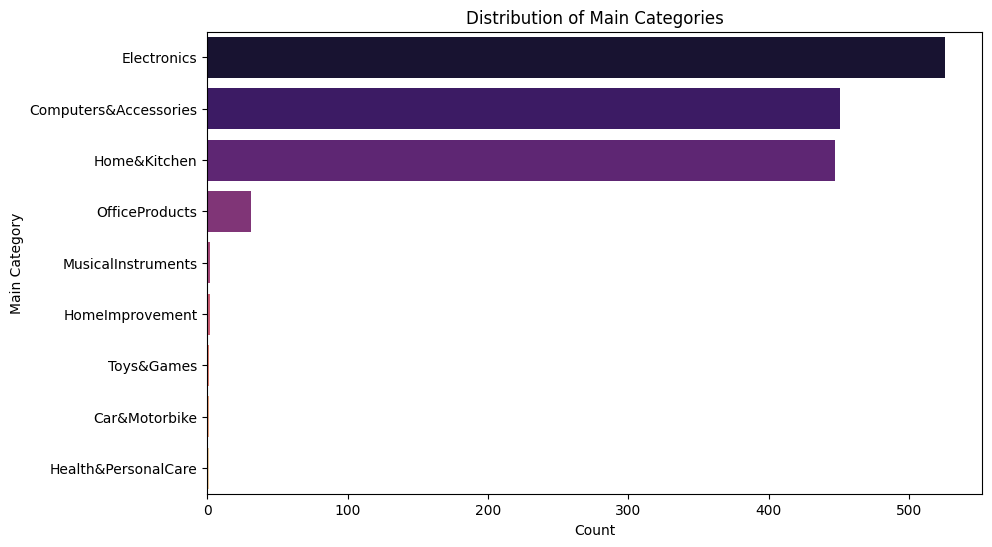

In [ ]:
plt.figure(figsize=(10,6))
sns.countplot(
    data=df,
    y="main category",
    order=df["main category"].value_counts().index,
    palette="magma"
)
plt.title("Distribution of Main Categories")
plt.xlabel("Count")
plt.ylabel("Main Category")
plt.show()

Business Question

Which product categories have the highest number of products listed on Amazon?

Observation

The distribution of products is uneven across categories. Technology-related categories, such as Electronics and Computers & Accessories, contain the highest number of listed products, while several other categories have a relatively smaller product selection.

/tmp/ipykernel_1353/3644499995.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


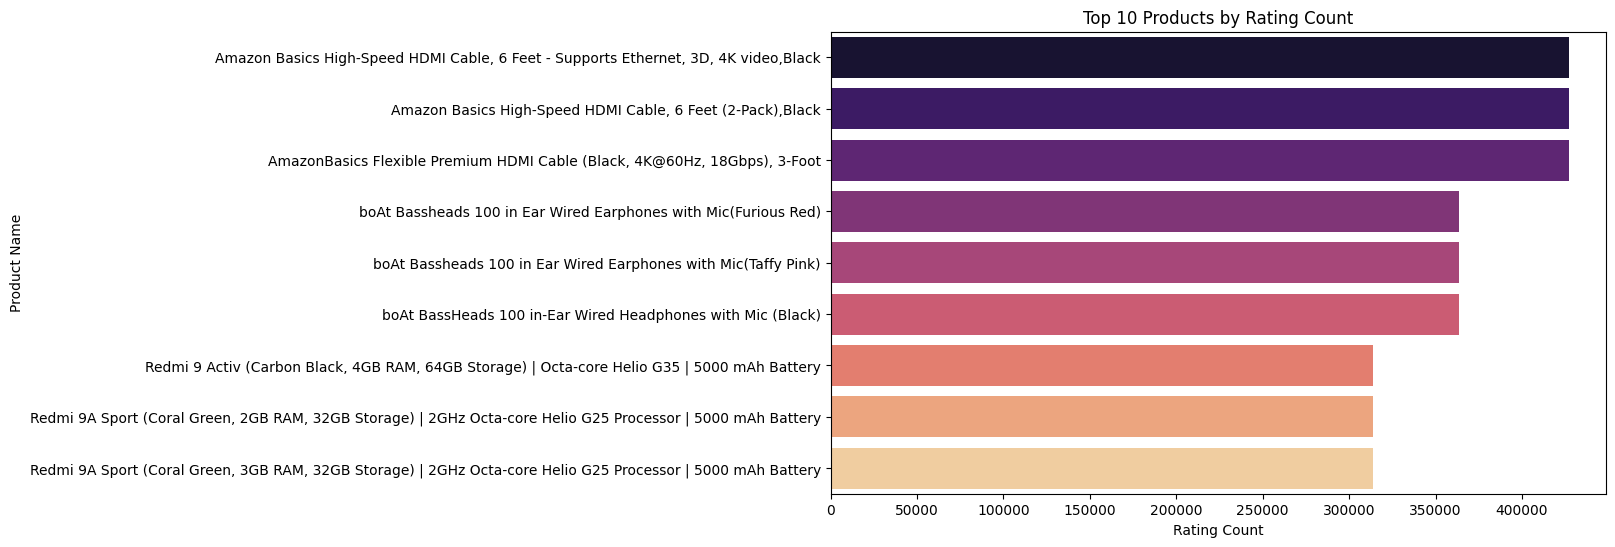

In [ ]:
top_reviews = (
    df[["product_name", "rating_count"]]
    .sort_values(by="rating_count", ascending=False)
    .head(10)
)
plt.figure(figsize=(10,6))
sns.barplot(
    data=top_reviews,
    x="rating_count",
    y="product_name",
    palette="magma"
)
plt.title("Top 10 Products by Rating Count")
plt.xlabel("Rating Count")
plt.ylabel("Product Name")
plt.show()

Business Question

Which products receive the highest level of customer engagement based on review count?

Observation

A small number of products have significantly higher review counts than others, indicating that customer engagement is concentrated among a few highly popular products.

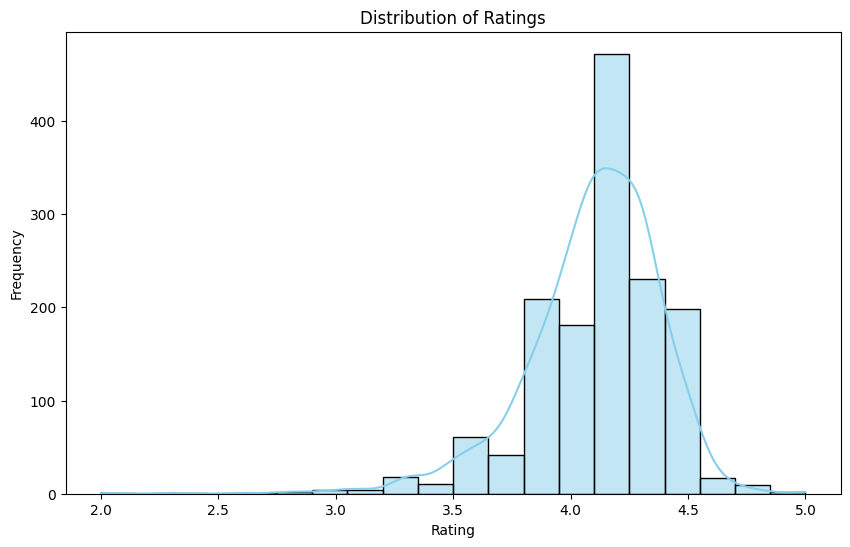

In [ ]:
plt.figure(figsize=(10,6))
sns.histplot(
    data=df,
    x="rating",
    bins=20,
    kde=True,
    color="skyblue"
)
plt.title("Distribution of Ratings")
plt.xlabel("Rating")
plt.ylabel("Frequency")
plt.show()


Business Question

How are customer ratings distributed across Amazon products?

Observation

Most products have ratings between 4.0 and 4.5, indicating that the majority of listed products receive positive customer feedback and maintain high customer satisfaction.

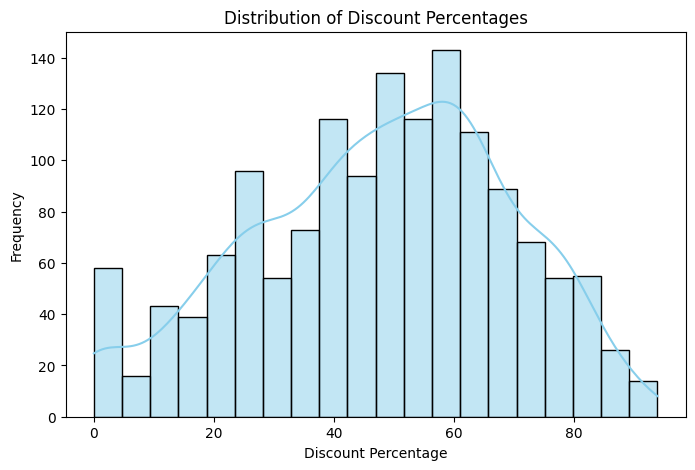

In [ ]:
plt.figure(figsize=(8, 5))
sns.histplot(
    data=df,
    x="discount_percentage",
    bins=20,
    kde=True,
    color="skyblue"
)
plt.title("Distribution of Discount Percentages")
plt.xlabel("Discount Percentage")
plt.ylabel("Frequency")
plt.show()

Business Question

How are discounts distributed across Amazon products?

Observation

Discount percentages vary across products, with most products offering moderate discounts. Extremely high discounts are comparatively less common.

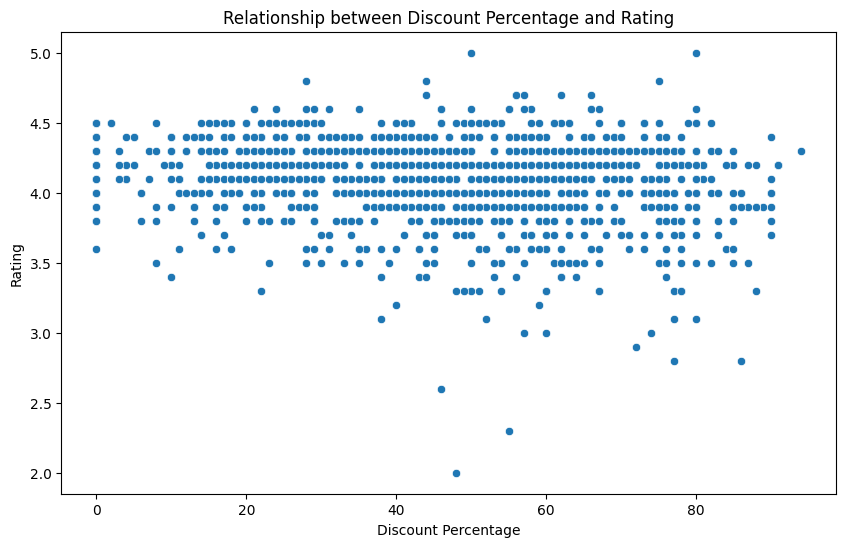

In [ ]:
plt.figure(figsize=(10,6))
sns.scatterplot(
    data=df,
    x="discount_percentage",
    y="rating"
)
plt.title("Relationship between Discount Percentage and Rating")
plt.xlabel("Discount Percentage")
plt.ylabel("Rating")
plt.show()


Business Question

Is there a relationship between discount percentage and customer ratings?

Observation

The scatter plot does not show a strong relationship between discount percentage and customer ratings. Products with both high and low discounts receive a wide range of ratings, suggesting that discounts alone do not determine customer satisfaction.

In [ ]:
numeric_df = df[
    [
        "discounted_price",
        "actual_price",
        "discount_percentage",
        "rating",
        "rating_count",
    ]
]

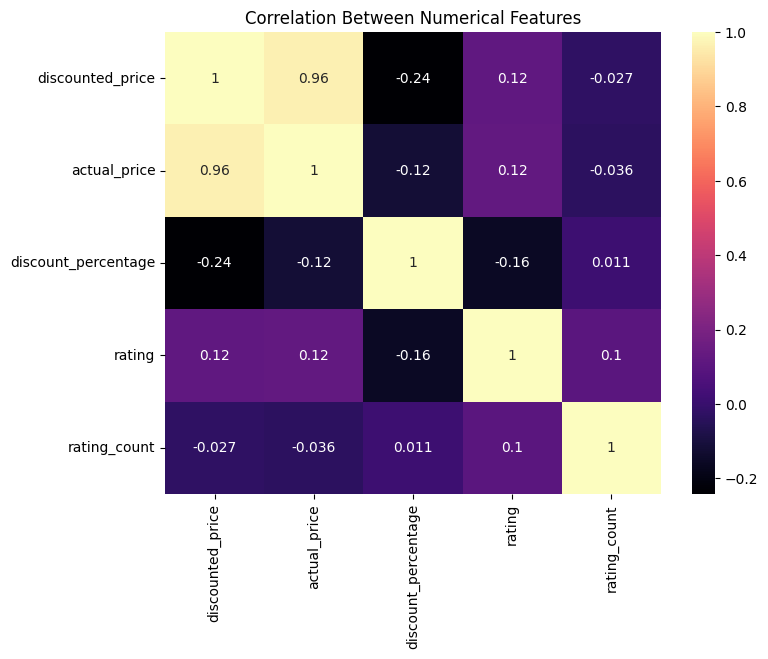

In [ ]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="magma"
)

plt.title("Correlation Between Numerical Features")

plt.show()

Business Question

What relationships exist among the numerical variables in the dataset?

Key Finding

The correlation analysis shows a strong positive relationship between actual price and discounted price, while variables such as discount percentage and customer rating exhibit weak correlations. This suggests that pricing variables are closely related, whereas customer ratings are influenced by factors beyond pricing.

In [ ]:
df.to_csv("amazon_cleaned_dataset.csv", index=False)

In [ ]:
from google.colab import files

files.download("amazon_cleaned_dataset.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

**Key Findings**

Technology-related categories, particularly Electronics and Computers & Accessories, dominate the product catalog.
Most products maintain customer ratings above 4.0, indicating high overall customer satisfaction.
Customer engagement is concentrated among a small number of highly reviewed products.
Discount percentages vary considerably across products, with moderate discounts being the most common.
No strong relationship exists between discount percentage and customer ratings, suggesting that discounts alone do not drive customer satisfaction.
Price-related variables exhibit a strong positive correlation, while customer ratings remain largely independent of pricing.

**Overall Conclusion**

This project analyzed Amazon product performance by examining product categories, pricing, discounts, customer ratings, and review counts. The analysis revealed that technology-related categories, particularly Electronics and Computers & Accessories, have a strong presence in the dataset, while most products receive relatively high customer ratings. The analysis also showed that discounts are commonly offered across products, but there is no strong relationship between discount percentage and customer ratings. Overall, the findings suggest that discounts alone may not be a key factor associated with customer ratings, highlighting the importance of considering product quality, customer experience, and other factors when evaluating product performance.